# WiniCari — 02 Preprocessing: GPS Trip Reconstruction

**Goal:** turn raw GPS pings (`Historique_pos`) into **reconstructed trips with a derived
actual arrival time per stop** — the shared foundation for Delay prediction (labels),
Anomaly detection and GPS Fallback.

**Why derive it:** `service` / `session_ouverte` only log when a driver *opens* a run. The
arrival at the terminus, the turnaround, and the **return trip are never logged** (a driver
typically opens one service for the whole day, `voyages` empty). So trips can only be
recovered from the **GPS track**.


In [1]:
from pathlib import Path
import sys
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.db import get_db
from src.data import foundation as fdn

db_winicari = get_db("winicari")
db_gps = get_db("Historique_pos")

CFG = fdn.Config()         
CFG

Config(min_anchors=4, min_pings=300, first_usable_day='d20220601', dedup_round=6, signal_gap_s=600, proj_window=3, proj_gap_reset_s=900, smooth_window=15, reversal_frac=0.15, reversal_floor_m=2000.0, min_span_frac=0.06, min_span_floor_m=1500.0, min_trip_min=8.0, layover_gap_s=2400, park_frac=0.05, full_frac=0.1, arrival_thresh_m=350.0)

## Line geometry — keep geocoded anchors, drop placeholders

`array_lat/lng_opendata` maps one coordinate per stop, but many stops are stored as `0.0`
(not geocoded). We keep the geocoded **anchors** in route order and skip the rest — partial
coverage, not a reason to drop a line. `code` is **not unique across companies**, so we key
everything by `(code, societe)`.

In [2]:
# One query builds {(code, societe) -> anchor stops with cumulative route distance}
USABLE = fdn.build_usable_lines(db_winicari, CFG)

n_zero = sum(len(fdn.real_anchor_stops(lg)) == 0
             for lg in db_winicari["ligne"].find({}, {"array_lat_opendata": 1,
                                                      "array_lng_opendata": 1}))
print(f"usable (code, societe) lines: {len(USABLE)} | lines with 0 geocoded stops: {n_zero}")
USABLE[("209", "S.R.T.K")].head()

usable (code, societe) lines: 135 | lines with 0 geocoded stops: 249


,seq,route_seq,name,lat,lon,s_m
0,0,0,KASSERINE,35.178056,8.847499,0.000000
1,1,1,BOUZGUEM,35.209142,8.894370,5485.235148
2,2,2,EL GARRAA,35.228854,8.960128,11848.232621
3,3,3,CHRAYA,35.255313,9.022020,18192.423815
4,4,4,SBEITLA,35.231061,9.130617,28416.628099


## Stop geometry audit — how complete is the network?

For every line we count: total stops declared, geocoded (real lat/lon), missing (stored as `0.0`).
We classify each line into one of five types:

| type | meaning |
|---|---|
| `full` | every stop geocoded |
| `partial` | some stops geocoded, some missing |
| `terminal_only` | only 1–2 stops geocoded (usually just origin + terminus) |
| `no_geometry` | stops declared but none geocoded |
| `no_stops` | no stop array at all in the config |

Lines classified `terminal_only` are the ones you suspected: route_km is just a straight-line
distance between the two endpoints — **not** the actual road distance.

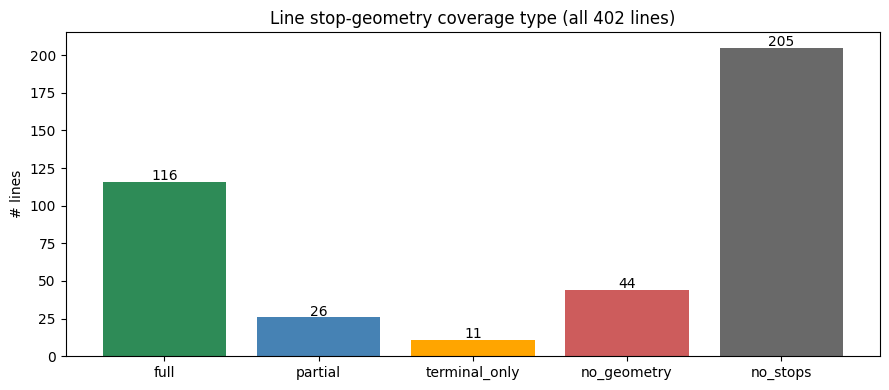

coverage_type
full             116
partial           26
terminal_only     11
no_geometry       44
no_stops         205

Total lines: 402  |  with any geometry: 153  |  blind (0 geocoded): 249


In [3]:
from pathlib import Path
import numpy as np

LD = Path(fdn.__file__).resolve().parents[2] / "data" / "processed" / "line_distances.parquet"
ld = pd.read_parquet(LD)

# ── 1. Coverage type breakdown ────────────────────────────────────────────────
ct = ld["coverage_type"].value_counts().reindex(
    ["full", "partial", "terminal_only", "no_geometry", "no_stops"])

plt.figure(figsize=(9, 4))
colors = ["seagreen", "steelblue", "orange", "indianred", "dimgrey"]
bars = plt.bar(ct.index, ct.values, color=colors)
for b, v in zip(bars, ct.values):
    plt.text(b.get_x() + b.get_width()/2, v + 1, str(v), ha="center", fontsize=10)
plt.ylabel("# lines"); plt.title("Line stop-geometry coverage type (all 402 lines)")
plt.tight_layout(); plt.show()

print(ct.to_string())
print(f"\nTotal lines: {len(ld)}  |  with any geometry: {(ld['geocoded_stops']>0).sum()}  "
      f"|  blind (0 geocoded): {(ld['geocoded_stops']==0).sum()}")

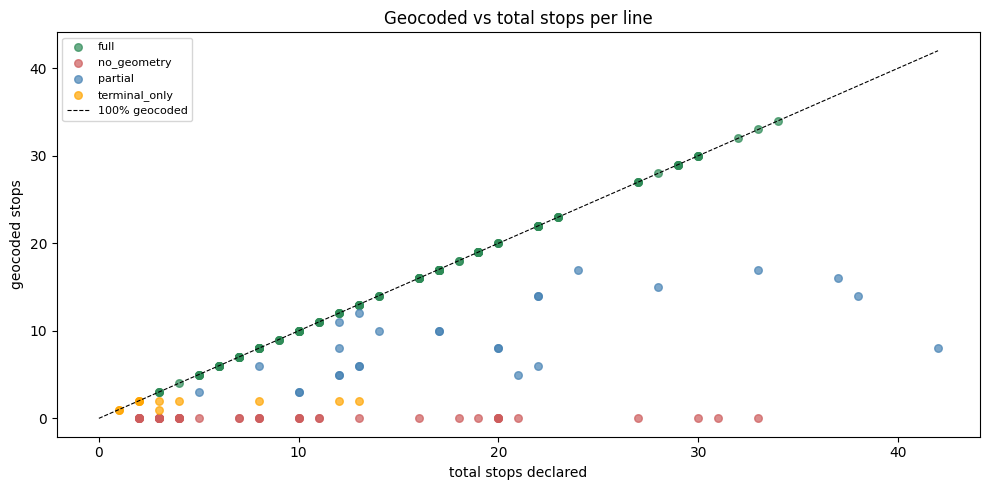

In [4]:
# ── 2. Missing vs geocoded stops per line (scatter) ──────────────────────────
has_stops = ld[ld["total_stops"] > 0].copy()
cmap = {"full":"seagreen","partial":"steelblue","terminal_only":"orange",
        "no_geometry":"indianred","no_stops":"dimgrey"}

plt.figure(figsize=(10, 5))
for ct_type, grp in has_stops.groupby("coverage_type"):
    plt.scatter(grp["total_stops"], grp["geocoded_stops"],
                label=ct_type, color=cmap.get(ct_type,"grey"), alpha=0.7, s=30)
plt.plot([0, has_stops["total_stops"].max()],
         [0, has_stops["total_stops"].max()],
         "k--", lw=0.8, label="100% geocoded")
plt.xlabel("total stops declared"); plt.ylabel("geocoded stops")
plt.title("Geocoded vs total stops per line")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

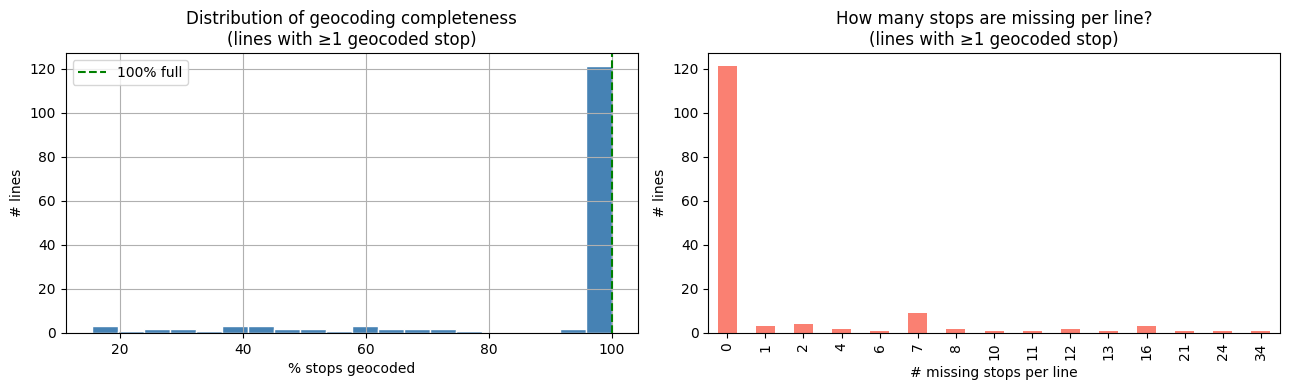

In [5]:
# ── 3. % geocoded distribution — how cut are the partial lines? ──────────────
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

has_geo = ld[ld["geocoded_stops"] > 0]
has_geo["pct_geocoded"].hist(bins=20, ax=ax[0], color="steelblue", edgecolor="white")
ax[0].axvline(100, color="green", ls="--", label="100% full")
ax[0].set_xlabel("% stops geocoded"); ax[0].set_ylabel("# lines")
ax[0].set_title("Distribution of geocoding completeness\n(lines with ≥1 geocoded stop)")
ax[0].legend()

# missing stops per line (for lines that have some geometry)
has_geo["missing_stops"].value_counts().sort_index().head(20).plot(kind="bar", ax=ax[1], color="salmon")
ax[1].set_xlabel("# missing stops per line"); ax[1].set_ylabel("# lines")
ax[1].set_title("How many stops are missing per line?\n(lines with ≥1 geocoded stop)")
plt.tight_layout(); plt.show()

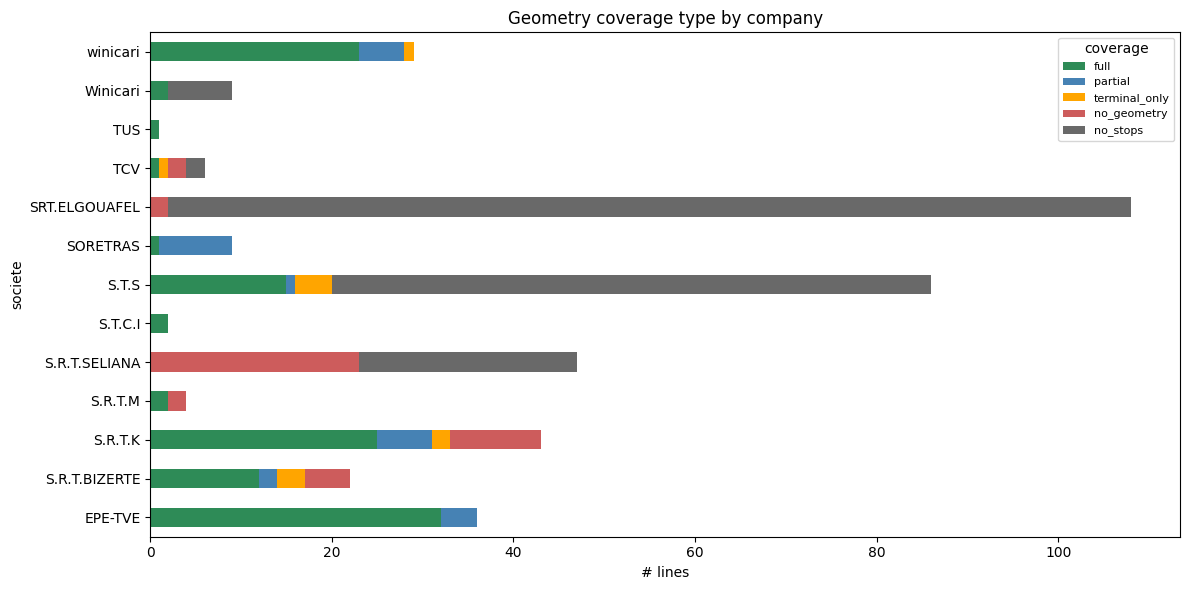


Terminal-only lines (11) — route_km is straight-line origin→terminus only:
    line        societe  total_stops  geocoded_stops  missing_stops  route_km
16   116  S.R.T.BIZERTE            2               2              0    41.394
17   103  S.R.T.BIZERTE            2               2              0    54.452
30   102  S.R.T.BIZERTE            2               2              0    55.852
98   220          S.T.S           12               2             10    25.675
99   221          S.T.S            4               2              2   244.970
102  224          S.T.S           13               2             11     2.102
159  213          S.T.S            8               2              6    10.585
161  999        S.R.T.K            1               1              0     0.000
190  999       winicari            1               1              0     0.000
217  105        S.R.T.K            3               2              1     5.485
229    1            TCV            3               1              

In [6]:
# ── 4. By company: coverage type stacked bar ─────────────────────────────────
order = ["full", "partial", "terminal_only", "no_geometry", "no_stops"]
colors = {"full":"seagreen","partial":"steelblue","terminal_only":"orange",
          "no_geometry":"indianred","no_stops":"dimgrey"}

pivot = (ld.groupby(["societe","coverage_type"]).size()
           .unstack(fill_value=0)
           .reindex(columns=order, fill_value=0))

pivot.plot(kind="barh", stacked=True, figsize=(12, 6),
           color=[colors[c] for c in order])
plt.xlabel("# lines"); plt.title("Geometry coverage type by company")
plt.legend(title="coverage", bbox_to_anchor=(1,1), fontsize=8)
plt.tight_layout(); plt.show()

# terminal-only lines listed explicitly
show_cols = [c for c in ["line","societe","total_stops","geocoded_stops","missing_stops","route_km"] if c in ld.columns]
term = ld[ld["coverage_type"]=="terminal_only"][show_cols]
print(f"\nTerminal-only lines ({len(term)}) — route_km is straight-line origin→terminus only:")
print(term.to_string())

### What this means for the pipeline

- **`full` (116 lines):** all stops geocoded → route_km is accurate, match rate should be high.
- **`partial` (26 lines):** gaps in the middle → route_km underestimates (missing hops); match rate will be lower for missing stops. The pipeline skips `0.0` placeholders and uses the remaining anchors.
- **`terminal_only` (11 lines):** only origin + terminus geocoded → route_km is a **straight-line crow-flies distance**, shorter than the real road. The pipeline treats these as 2-anchor lines; `min_anchors=4` means they are **not usable** for trip reconstruction.
- **`no_geometry` (44 lines):** stops declared but coordinates all `0.0` → pipeline rejects them entirely.
- **`no_stops` (205 lines):** no stop array at all → most are SRT.ELGOUAFEL and S.R.T.SELIANA. Pipeline cannot use them. The only fix is for those companies to geocode their stops.

## 1. Load + clean one bus-day

`load_pings` normalizes the schema drift (`localisation.x=lat`, `.y=lon`; speed = top-level
`speed` else `bus.vitesse`). `clean_pings` drops consecutive stationary duplicates (~10%)
and flags signal gaps. We fix one clean intercity example for reproducibility.

In [7]:
#show the actual stop names for a given line and all the informations realted to them like the stop time the coordinates and the distance between the stops in an ordered way way


In [8]:
LINE, SOCIETE, BUS, DAY = "209", "S.R.T.K", 6030, "d20260615"
stops = USABLE[(LINE, SOCIETE)]

raw = fdn.load_pings(db_gps, DAY, LINE, BUS)
g = fdn.clean_pings(raw, CFG)
print(f"line {LINE} {SOCIETE} bus {BUS} {DAY[1:]} | stops={len(stops)}")
print(f"raw pings {len(raw)} -> cleaned {len(g)} (removed {len(raw)-len(g)} stationary, "
      f"{100*(len(raw)-len(g))//len(raw)}%) | median interval {g['gap_s'].median():.0f}s "
      f"| signal gaps {int(g['signal_gap'].sum())} | largest {g['gap_s'].max():.0f}s")
g.head()

line 209 S.R.T.K bus 6030 20260615 | stops=22
raw pings 4023 -> cleaned 3582 (removed 441 stationary, 10%) | median interval 5s | signal gaps 4 | largest 3607s


,t,lat,lon,speed,gap_s,signal_gap
0,2026-06-15 09:51:43.431,35.177807,8.847803,0.00000,NaN,False
1,2026-06-15 09:53:08.483,35.177807,8.847807,0.00000,85.052,False
2,2026-06-15 09:53:18.483,35.177807,8.847805,0.14816,10.000,False
3,2026-06-15 09:53:58.500,35.177807,8.847807,0.00000,40.017,False
4,2026-06-15 09:54:58.518,35.177807,8.847805,0.00000,60.018,False


## 2. Map-match each ping to a route distance

`project_to_route` does a **sequential (windowed) projection** onto the anchor polyline,
giving a smooth distance-along-route `s` (and off-route `off_m`). The windowing keeps `s`
physically smooth despite sparse anchors — the key to clean segmentation.

route length (anchor polyline): 192 km | mean off-route distance: 336 m


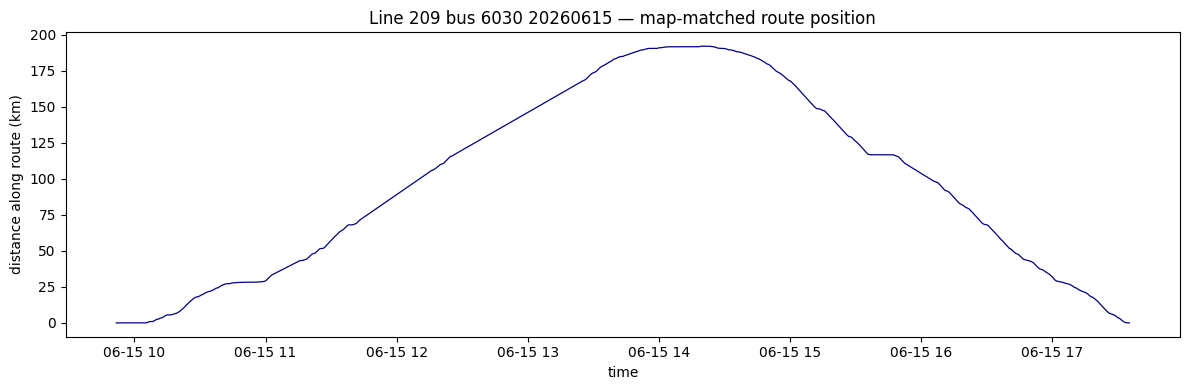

In [9]:
g, route_len = fdn.project_to_route(g, stops, CFG)
print(f"route length (anchor polyline): {route_len/1000:.0f} km | "
      f"mean off-route distance: {g['off_m'].mean():.0f} m")

plt.figure(figsize=(12, 4))
plt.plot(g["t"], g["s"] / 1000, linewidth=0.9, color="navy")
plt.ylabel("distance along route (km)"); plt.xlabel("time")
plt.title(f"Line {LINE} bus {BUS} {DAY[1:]} — map-matched route position")
plt.tight_layout(); plt.show()

## 3. Segment trips — full **and** partial

`segment_trips` detects **direction swings** (turnarounds) using a scale-invariant
hysteresis (fraction of route length), so it works for a 200 km intercity line and a 6 km
urban loop alike. It splits a same-direction run **only** at a *parked* layover gap (big
time gap where the bus barely moved) — so a mid-route signal gap does **not** fragment one
run, and a bus that turns back early is kept as a **partial** trip.

detected 2 trips (2 full, 0 partial)
      dir  full  start    end     km
0   ALLER  True  09:51  14:19  192.0
1  RETOUR  True  14:19  17:35  192.0


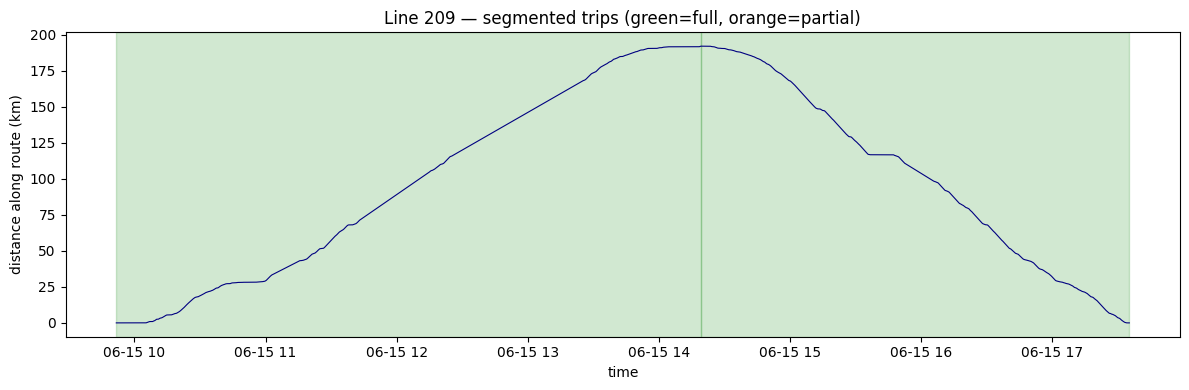

In [10]:
trips = fdn.segment_trips(g, route_len, CFG)
view = trips.assign(start=trips["start"].dt.strftime("%H:%M"),
                    end=trips["end"].dt.strftime("%H:%M"),
                    km=((trips["s_hi"] - trips["s_lo"]) / 1000).round(1))[
    ["dir", "full", "start", "end", "km"]]
print(f"detected {len(trips)} trips ({trips['full'].sum()} full, {(~trips['full']).sum()} partial)")
print(view.to_string())

plt.figure(figsize=(12, 4))
plt.plot(g["t"], g["s"] / 1000, linewidth=0.8, color="navy")
for _, tr in trips.iterrows():
    plt.axvspan(tr["start"], tr["end"], alpha=0.18,
                color="green" if tr["full"] else "orange")
plt.ylabel("distance along route (km)"); plt.xlabel("time")
plt.title(f"Line {LINE} — segmented trips (green=full, orange=partial)")
plt.tight_layout(); plt.show()



## 4. Derive actual arrival time per stop

For each trip, `derive_arrivals` snaps the stops within the trip's covered range to pings
**in travel order**, enforcing monotonically increasing arrival times. Match rate is itself
a per-line data-quality signal.

In [11]:
tr = trips.iloc[0]
arr = fdn.derive_arrivals(g, tr, stops, CFG)
print(f"Trip 0 ({tr['dir']}, full={tr['full']}): matched {arr['matched'].sum()}/{len(arr)} "
      f"covered stops ({arr['matched'].mean():.0%})")
arr.assign(arrival=arr["arrival"].dt.strftime("%H:%M:%S"))

Trip 0 (ALLER, full=True): matched 13/22 covered stops (59%)


,seq,route_seq,stop,arrival,departure,dwell_s,dist_m,matched
0,0,0,KASSERINE,09:55:18,2026-06-15 10:05:32.434,613.9,39,True
1,1,1,BOUZGUEM,10:14:53,2026-06-15 10:17:23.494,150.0,6,True
2,2,2,EL GARRAA,10:23:27,2026-06-15 10:23:37.524,10.0,136,True
3,3,3,CHRAYA,10:29:17,2026-06-15 10:29:32.632,15.0,20,True
4,4,4,SBEITLA,10:57:40,2026-06-15 10:58:55.358,75.1,113,True
5,5,5,OUED ELMIOU,NaN,NaT,NaN,2927,False
6,6,6,ESSABALA,11:16:22,2026-06-15 11:17:27.498,65.0,38,True
7,7,7,EL BLAKAT,11:24:52,2026-06-15 11:26:27.676,95.0,35,True
8,8,8,M'AMMER,11:31:17,2026-06-15 11:31:27.735,10.0,12,True
9,9,9,BLAK BOUZID,11:40:09,2026-06-15 11:40:44.413,35.0,1,True


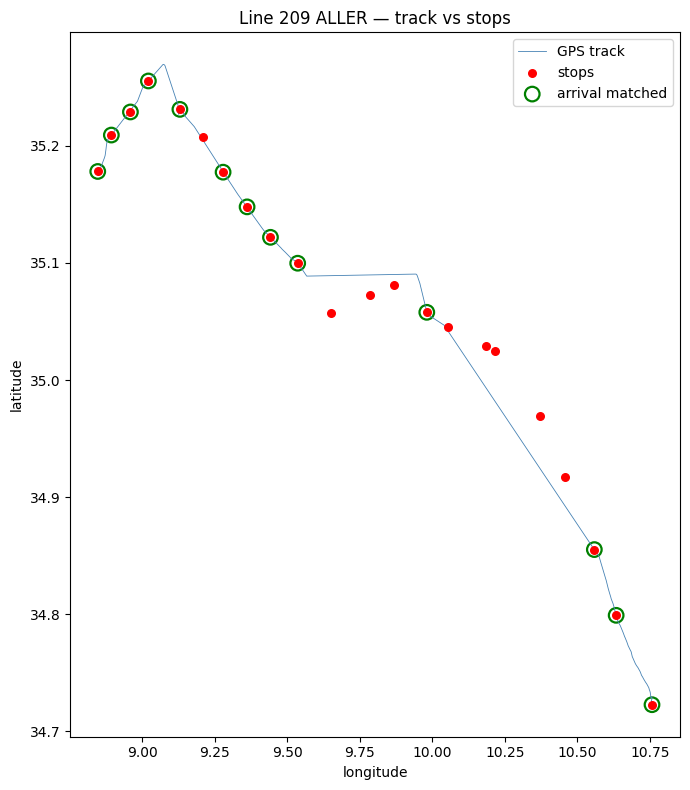

In [12]:
# Map view: route stops + the bus track + matched arrivals for trip 0
seg = g[(g["t"] >= tr["start"]) & (g["t"] <= tr["end"])]
matched = arr[arr["matched"]]
plt.figure(figsize=(7, 8))
plt.plot(seg["lon"], seg["lat"], linewidth=0.6, color="steelblue", label="GPS track")
plt.scatter(stops["lon"], stops["lat"], c="red", s=30, zorder=3, label="stops")
plt.scatter([stops["lon"].iloc[s] for s in matched["seq"]],
            [stops["lat"].iloc[s] for s in matched["seq"]],
            facecolors="none", edgecolors="green", s=110, linewidths=1.6, label="arrival matched")
plt.xlabel("longitude"); plt.ylabel("latitude")
plt.title(f"Line {LINE} {tr['dir']} — track vs stops"); plt.legend()
plt.tight_layout(); plt.show()

## 5. Full pipeline for one bus-day

`reconstruct_bus_day` chains all of the above and returns one row per covered stop-arrival.

In [13]:
demo = fdn.reconstruct_bus_day(db_gps, DAY, LINE, SOCIETE, BUS, stops, CFG)
print(f"rows={len(demo)} | trips={demo['trip_id'].nunique()} | "
      f"match rate={100*demo['matched'].mean():.0f}%")
print("columns:", list(demo.columns))
demo.head(12)

rows=44 | trips=2 | match rate=75%
columns: ['day', 'line', 'societe', 'bus', 'trip_id', 'dir', 'full', 'trip_start', 'trip_end', 'seq', 'route_seq', 'stop', 'arrival', 'departure', 'dwell_s', 'dist_m', 'matched']


,day,line,societe,bus,trip_id,dir,full,trip_start,trip_end,seq,route_seq,stop,arrival,departure,dwell_s,dist_m,matched
0,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,0,0,KASSERINE,2026-06-15 09:55:18.519,2026-06-15 10:05:32.434,613.9,39,True
1,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,1,1,BOUZGUEM,2026-06-15 10:14:53.457,2026-06-15 10:17:23.494,150.0,6,True
2,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,2,2,EL GARRAA,2026-06-15 10:23:27.524,2026-06-15 10:23:37.524,10.0,136,True
3,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,3,3,CHRAYA,2026-06-15 10:29:17.632,2026-06-15 10:29:32.632,15.0,20,True
4,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,4,4,SBEITLA,2026-06-15 10:57:40.230,2026-06-15 10:58:55.358,75.1,113,True
5,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,5,5,OUED ELMIOU,NaT,NaT,NaN,2927,False
6,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,6,6,ESSABALA,2026-06-15 11:16:22.479,2026-06-15 11:17:27.498,65.0,38,True
7,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,7,7,EL BLAKAT,2026-06-15 11:24:52.626,2026-06-15 11:26:27.676,95.0,35,True
8,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,8,8,M'AMMER,2026-06-15 11:31:17.734,2026-06-15 11:31:27.735,10.0,12,True
9,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,9,9,BLAK BOUZID,2026-06-15 11:40:09.397,2026-06-15 11:40:44.413,35.0,1,True


## 6. Batch + persist (production)

The dataset is built by the resumable CLI, which loops every usable `(day, line, societe,
bus)` and writes monthly parquet shards, then combines them:

```bash
python -m src.data.build_foundation                 # full usable range (>= 2022-06, ~40 min)
python -m src.data.build_foundation --since 202501  # only months >= 2025-01
```

Below we **load** the persisted dataset and analyze it — no heavy compute in the notebook.

In [14]:
# repo root resolved from the library location -> works regardless of cwd
OUT = Path(fdn.__file__).resolve().parents[2] / "data" / "processed" / "foundation_arrivals_full.parquet"
if OUT.exists():
    fa = pd.read_parquet(OUT)
    bd = fa.groupby(["day", "line", "societe", "bus"]).ngroups
    tr_n = fa.groupby(["day", "line", "societe", "bus", "trip_id"]).ngroups
    print(f"loaded {OUT.name}: rows={len(fa)} | bus-days={bd} | trips={tr_n} "
          f"| lines={fa['line'].nunique()} | overall match={100*fa['matched'].mean():.0f}%")
    print(f"day range: {fa['day'].min()} .. {fa['day'].max()} | "
          f"full trips={fa.groupby(['day','line','bus','trip_id'])['full'].first().sum()}")
else:
    fa = pd.DataFrame()
    print(f"{OUT} not found — run the CLI above to build it.")
fa.head()

loaded foundation_arrivals_full.parquet: rows=168481 | bus-days=3343 | trips=20743 | lines=29 | overall match=77%


day range: 20250101 .. 20260621 | full trips=17341


,day,line,societe,bus,trip_id,dir,full,trip_start,trip_end,seq,route_seq,stop,arrival,dist_m,matched
0,20250101,217,S.R.T.K,6036,0,ALLER,True,2025-01-01 03:00:52.299,2025-01-01 07:51:24.201,0,0,KASSERINE,2025-01-01 03:01:22.300,92.0,True
1,20250101,217,S.R.T.K,6036,0,ALLER,True,2025-01-01 03:00:52.299,2025-01-01 07:51:24.201,1,1,BOUZGUEM,2025-01-01 03:14:07.268,46.0,True
2,20250101,217,S.R.T.K,6036,0,ALLER,True,2025-01-01 03:00:52.299,2025-01-01 07:51:24.201,2,2,EL GARRAA,NaT,1238.0,False
3,20250101,217,S.R.T.K,6036,0,ALLER,True,2025-01-01 03:00:52.299,2025-01-01 07:51:24.201,3,3,CHRAYA,2025-01-01 03:24:01.335,17.0,True
4,20250101,217,S.R.T.K,6036,0,ALLER,True,2025-01-01 03:00:52.299,2025-01-01 07:51:24.201,4,4,SBEITLA,2025-01-01 03:39:24.278,118.0,True


bus_days  trips  stops  match_rate
societe line                                    
S.T.S   107          1     34     34       100.0
S.R.T.K 501          2      3      3       100.0
S.T.S   225          3     73     73        99.0
S.R.T.K 306        144   1054   1054        95.0
S.T.S   216          7     33     33        88.0
        301         28    850    850        87.0
        306         52   2538   2538        85.0
S.R.T.K 211          5     87     87        85.0
        415          4     31     31        84.0
TCV     3          405  85412  85412        83.0
S.T.S   226         19    725    725        82.0
        219         62  11732  11732        80.0
S.R.T.K 202        115   4749   4749        80.0
        428          6     42     42        79.0
S.T.S   211         37   1251   1251        79.0
S.R.T.K 500         10    108    108        79.0
S.T.S   101        145   6582   6582        77.0
        304        226  10506  10506        75.0
S.R.T.K 209        127   4922   4922        74.0
        217        153   7699   7699        70.0
S.T.S   541          2    122    122        70.0
S.R.T.K 216         30   1413   1413        69.0
        203        147   5513   5513        68.0
        204        116   3811   3811        68.0
S.T.S   215          8     94     94        64.0
S.R.T.K 215        148   6207   6207        61.0
        205         13    129    129        61.0
        311          5     50     50        60.0
        212        280  12552  12552        55.0
        201          6    140    140        54.0
        402          1      5      5        40.0
S.T.S   515          1      9      9        33.0
        212          1      4      4         0.0
S.R.T.K 424          1      1      1         0.0

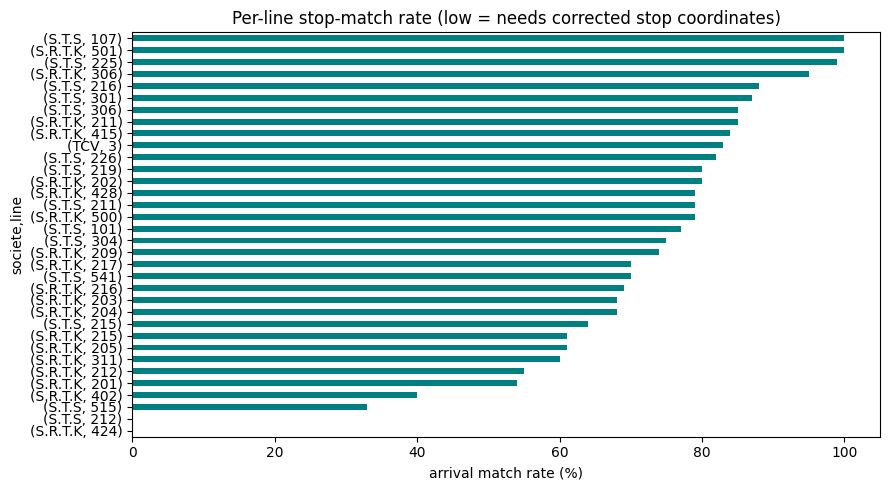

In [15]:
# Per-line match rate = headline data-quality signal (which lines have good stop coords)
if len(fa):
    per_line = (fa.groupby(["societe", "line"])
                  .agg(bus_days=("day", "nunique"), trips=("trip_id", "size"),
                       stops=("matched", "size"), match_rate=("matched", "mean"))
                  .assign(match_rate=lambda d: (100 * d["match_rate"]).round())
                  .sort_values("match_rate", ascending=False))
    display(per_line)

    ax = per_line["match_rate"].plot(kind="barh", figsize=(9, 5), color="teal")
    ax.set_xlabel("arrival match rate (%)")
    ax.set_title("Per-line stop-match rate (low = needs corrected stop coordinates)")
    ax.invert_yaxis(); plt.tight_layout(); plt.show()

### Caveats / quality notes (feed back to the audit)

- **Geometry is partial:** ~135 lines usable (>= 4 geocoded anchors); ~249 have none. Sparse
  anchors mean the polyline only approximates the road — segmentation uses distance *swings*
  with hysteresis rather than exact map-matching for robustness.
- **Match rate per line is the quality metric.** Well-mapped intercity lines score high; short
  urban lines and lines with imprecise stop coords (e.g. some S.R.T.K lines) score low and
  should get corrected coordinates from the company before they're model-ready.
- **Partial trips are kept** (bus turns back early, or day ends mid-run) and flagged via
  `full=False`; mid-route signal gaps do not fragment a run.
- **No scheduled per-stop times exist yet** to subtract — `ligne.horaires` only holds
  departure times. Delay labelling (actual − scheduled) is the next notebook once schedules
  are mapped per stop.
- All tunables live in `fdn.Config`; the same code path runs in the notebook and the CLI.